In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import seaborn as sns

In [19]:
df_ssd_and_wood_density = pd.read_csv("ssd_and_wood_density.csv")
df_gift_ssd = pd.read_csv("GIFT-db_traits/GIFT-db_ssd.csv")
bien_swd = pd.read_csv("bien_traits_summary/bien_summary_stem_wood_density.csv")

In [21]:
df_ssd_and_wood_density = df_ssd_and_wood_density.rename(
    columns={
        "trait_value_SSD_mean": "gift_ssd_g_cm3",
        "stem_wood_density_g_cm3_mean": "bien_wood_density_g_cm3",
        "ssd_mean_g_cm3": "measured_ssd_g_cm3"
    }
)

df_ssd_and_wood_density = df_ssd_and_wood_density.drop_duplicates(subset="work_species")
df_ssd_and_wood_density

,work_species,gift_ssd_g_cm3,bien_wood_density_g_cm3,measured_ssd_g_cm3
0,aesculus hippocastanum,0.5100,0.500000,0.586531
1,buxus sempervirens,0.9100,0.780000,0.719884
2,castanea sativa,0.5000,0.463333,0.602064
3,casuarina cunninghamiana,0.8030,0.659303,0.698443
4,casuarina equisetifolia,0.8590,0.808789,0.805441
5,casuarina glauca,0.7840,0.734994,0.768280
6,cornus controversa,0.6210,0.513227,0.563121
7,cryptomeria japonica,0.3410,0.360730,0.363763
8,delonix regia,0.5190,0.578687,0.603222
9,eucalyptus camaldulensis,0.6620,0.721110,0.718474


In [11]:
df_ssd_and_wood_density.describe()

,gift_ssd_g_cm3,bien_wood_density_g_cm3,measured_ssd_g_cm3
count,23.000000,23.000000,23.000000
mean,0.692326,0.621462,0.669183
std,0.161545,0.157032,0.130959
min,0.341000,0.360730,0.363763
25%,0.600000,0.506614,0.579750
50%,0.662000,0.578687,0.651853
75%,0.793500,0.729615,0.742981
max,0.990000,0.990000,0.990000


In [12]:
# Correlation matrix
df_ssd_and_wood_density[
    ["gift_ssd_g_cm3", "bien_wood_density_g_cm3", "measured_ssd_g_cm3"]
].corr()

,gift_ssd_g_cm3,bien_wood_density_g_cm3,measured_ssd_g_cm3
gift_ssd_g_cm3,1.000000,0.891357,0.806288
bien_wood_density_g_cm3,0.891357,1.000000,0.852538
measured_ssd_g_cm3,0.806288,0.852538,1.000000


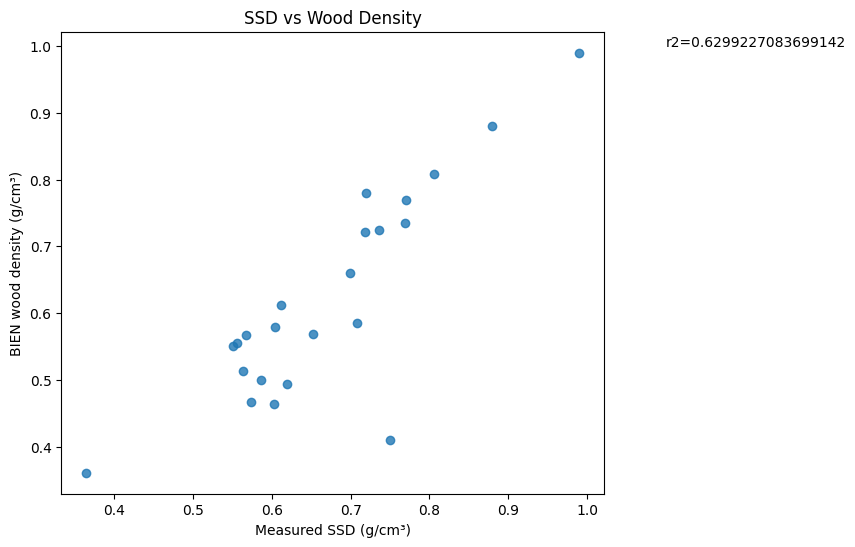

In [38]:
# Scatter plot: SSD vs wood density
x = df_ssd_and_wood_density["measured_ssd_g_cm3"]
y = df_ssd_and_wood_density["bien_wood_density_g_cm3"]

r2 = r2_score(y, x)

plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("Measured SSD (g/cm³)")
plt.ylabel("BIEN wood density (g/cm³)")
plt.title("SSD vs Wood Density")
plt.text(1.1,1,f"r2={r2}")
plt.savefig("SSD vs wood density.png")
plt.show()

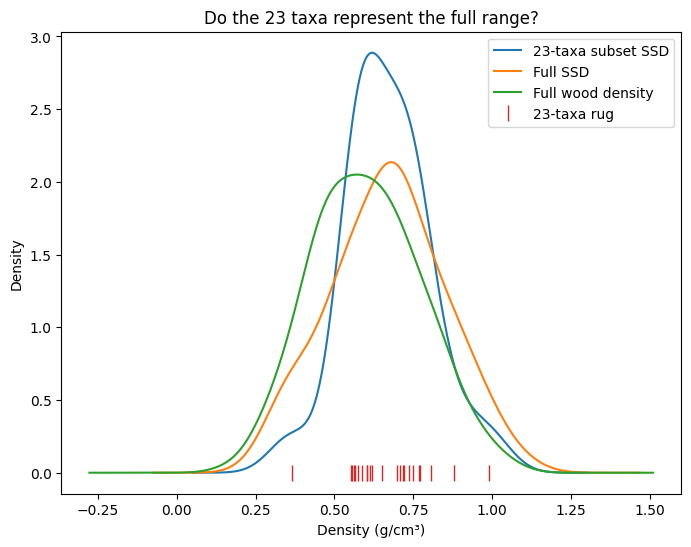

In [37]:
# KDE plot
subset_vals = df_ssd_and_wood_density["measured_ssd_g_cm3"].dropna()
full_ssd_vals = (df_gift_ssd["trait_value_SSD_mean"] / 1000).dropna()
full_wood_vals = bien_swd["stem_wood_density_g_cm3_mean"].dropna()

plt.figure(figsize=(8, 6))

subset_vals.plot(kind="density", label="23-taxa subset SSD")
full_ssd_vals.plot(kind="density", label="Full SSD")
full_wood_vals.plot(kind="density", label="Full wood density")

plt.plot(subset_vals, np.zeros(len(subset_vals)), "|", markersize=12, label="23-taxa rug")

plt.xlabel("Density (g/cm³)")
plt.ylabel("Density")
plt.title("Do the 23 taxa represent the full range?")
plt.legend()
plt.savefig("Do the 23 taxa represent the full range.png")
plt.show()

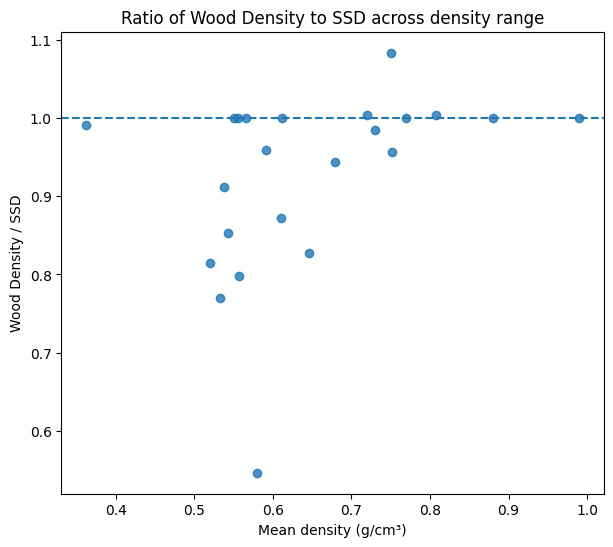

In [36]:
# Ratio analysis
ratio_df = df_ssd_and_wood_density[
    ["work_species", "measured_ssd_g_cm3", "bien_wood_density_g_cm3"]
].dropna().copy()

ratio_df["mean_density"] = (
    ratio_df["measured_ssd_g_cm3"] + ratio_df["bien_wood_density_g_cm3"]
) / 2

ratio_df["wd_over_ssd"] = (
    ratio_df["bien_wood_density_g_cm3"] / ratio_df["measured_ssd_g_cm3"]
)

plt.figure(figsize=(7, 6))
plt.scatter(ratio_df["mean_density"], ratio_df["wd_over_ssd"], alpha=0.8)
plt.axhline(1, linestyle="--")
plt.xlabel("Mean density (g/cm³)")
plt.ylabel("Wood Density / SSD")
plt.title("Ratio of Wood Density to SSD across density range")
plt.savefig("Ratio of Wood Density to SSD across density range.png")
plt.show()

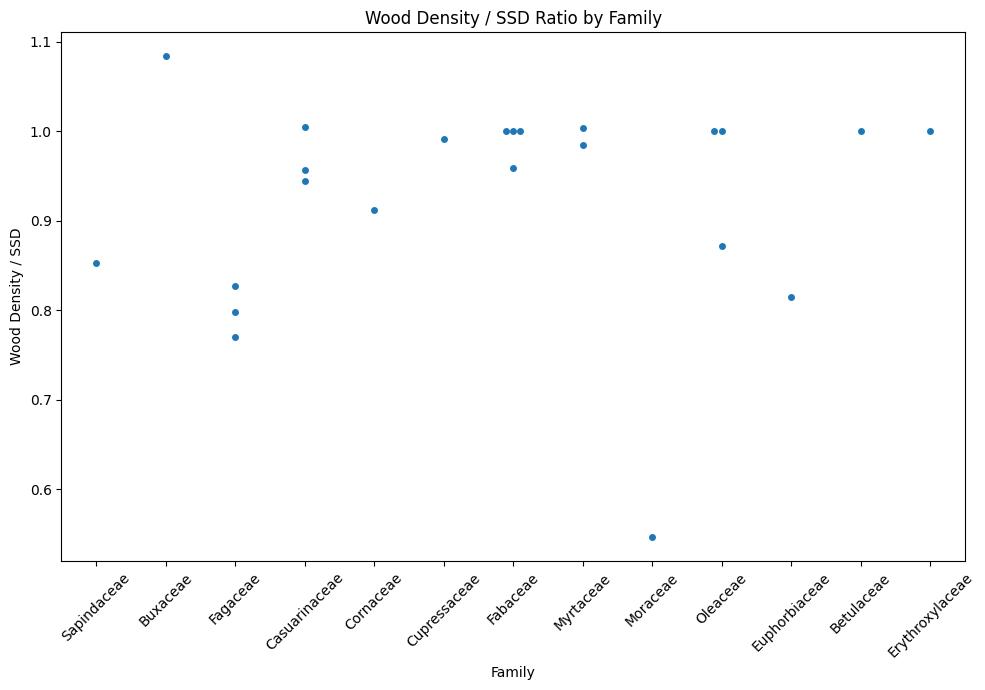

In [60]:
# boxplot of the ratio grouped by family
family_map = {
    "aesculus hippocastanum": "Sapindaceae",
    "buxus sempervirens": "Buxaceae",
    "castanea sativa": "Fagaceae",
    "casuarina cunninghamiana": "Casuarinaceae",
    "casuarina equisetifolia": "Casuarinaceae",
    "casuarina glauca": "Casuarinaceae",
    "cornus controversa": "Cornaceae",
    "cryptomeria japonica": "Cupressaceae",
    "delonix regia": "Fabaceae",
    "eucalyptus camaldulensis": "Myrtaceae",
    "eucalyptus globulus": "Myrtaceae",
    "fagus sylvatica": "Fagaceae",
    "ficus microcarpa": "Moraceae",
    "fraxinus chinensis": "Oleaceae",
    "fraxinus excelsior": "Oleaceae",
    "fraxinus mandshurica": "Oleaceae",
    "hevea brasiliensis": "Euphorbiaceae",
    "dalbergia cochinchinensis": "Fabaceae",
    "dalbergia cultrata": "Fabaceae",
    "castanopsis eyrei": "Fagaceae",
    "gleditsia sinensis": "Fabaceae",
    "corylus chinensis": "Betulaceae",
    "erythroxylum havanense": "Erythroxylaceae",
}

plot_df = df_ssd_and_wood_density.copy()
plot_df["work_species"] = plot_df["work_species"].str.lower()
plot_df["family"] = plot_df["work_species"].map(family_map)

plot_df["wd_over_ssd"] = (
    plot_df["bien_wood_density_g_cm3"] / plot_df["measured_ssd_g_cm3"]
)

plot_df = plot_df.dropna(subset=["family", "wd_over_ssd"])
plt.figure(figsize=(10, 7))

sns.swarmplot(data=plot_df, x="family", y="wd_over_ssd")


plt.xlabel("Family")
plt.ylabel("Wood Density / SSD")
plt.title("Wood Density / SSD Ratio by Family")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Wood Density vs SSD Ratio by Family.png")
plt.show()